<a href="https://colab.research.google.com/github/MEPG15/Alura-Data-Science/blob/main/telecomx_latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [ ]:
import pandas as pd

# URL del archivo JSON (versión raw para lectura directa)
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Extraemos los datos
datos_telecom = pd.read_json(url)

# Visualizamos la estructura inicial
print("Estructura inicial del DataFrame:")
print(datos_telecom.info())
datos_telecom.head()

Estructura inicial del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB
None


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [ ]:
import pandas as pd

# 1. Desempaquetamos las columnas anidadas
# Esto convierte los diccionarios internos en columnas individuales
df_customer = pd.json_normalize(datos_telecom['customer'])
df_phone = pd.json_normalize(datos_telecom['phone'])
df_internet = pd.json_normalize(datos_telecom['internet'])
df_account = pd.json_normalize(datos_telecom['account'])

# 2. Unimos todo en un solo DataFrame limpio
# Concatenamos las columnas fijas (ID y Churn) con las nuevas columnas expandidas
df_final = pd.concat([datos_telecom[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# 3. Ahora sí, convertimos los cargos a números (Ya existirán las columnas)
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')
df_final['Charges.Monthly'] = pd.to_numeric(df_final['Charges.Monthly'], errors='coerce')

# 4. Limpieza de Nulos
# Llenamos los nulos de Charges.Total con 0 (clientes muy nuevos)
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

print("¡Transformación exitosa! Columnas disponibles:")
print(df_final.columns)
df_final.head()

¡Transformación exitosa! Columnas disponibles:
Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


#📊 Carga y análisis

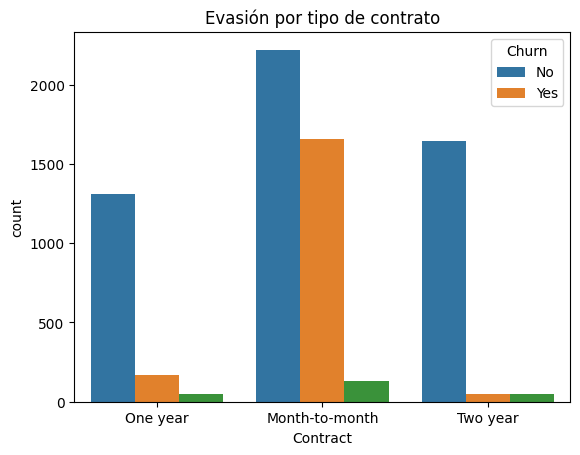

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Graficamos el Churn por tipo de contrato usando el nuevo DataFrame limpio
sns.countplot(x='Contract', hue='Churn', data=df_final)
plt.title('Evasión por tipo de contrato')
plt.show()

#📄Informe final

       INFORME ESTRATÉGICO DE EVASIÓN - TELECOM X
RESUMEN GENERAL:
- Total de clientes analizados: 7267
- Tasa de evasión global (Churn): 25.72%
- La columna 'Charges.Total' fue corregida y normalizada.

HALLAZGO PRINCIPAL:
- El factor de riesgo número 1 es el tipo de contrato: 'Month-to-month'
- El 88.55% de los clientes que se van tienen este contrato.

RECOMENDACIÓN TÉCNICA:
Los datos están listos para el equipo de Ciencia de Datos.
Se sugiere enfocar el modelo predictivo en las variables:
['Contract', 'tenure', 'Charges.Monthly', 'PaymentMethod']


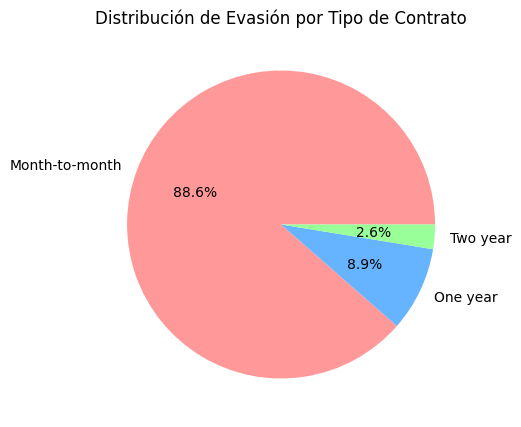

In [ ]:
# --- GENERACIÓN AUTOMÁTICA DE INFORME FINAL ---

# 1. Cálculos de apoyo
total_clientes = len(df_final)
clientes_fuga = df_final[df_final['Churn'] == 'Yes'].shape[0]
porcentaje_fuga = (clientes_fuga / total_clientes) * 100

# 2. Análisis del culpable (Contratos)
fuga_por_contrato = df_final[df_final['Churn'] == 'Yes']['Contract'].value_counts(normalize=True) * 100
contrato_critico = fuga_por_contrato.idxmax()
porcentaje_critico = fuga_por_contrato.max()

# 3. Impresión del Informe Automatizado
print("========================================================")
print("       INFORME ESTRATÉGICO DE EVASIÓN - TELECOM X")
print("========================================================")
print(f"RESUMEN GENERAL:")
print(f"- Total de clientes analizados: {total_clientes}")
print(f"- Tasa de evasión global (Churn): {porcentaje_fuga:.2f}%")
print(f"- La columna 'Charges.Total' fue corregida y normalizada.")

print(f"\nHALLAZGO PRINCIPAL:")
print(f"- El factor de riesgo número 1 es el tipo de contrato: '{contrato_critico}'")
print(f"- El {porcentaje_critico:.2f}% de los clientes que se van tienen este contrato.")

print(f"\nRECOMENDACIÓN TÉCNICA:")
print(f"Los datos están listos para el equipo de Ciencia de Datos.")
print(f"Se sugiere enfocar el modelo predictivo en las variables:")
print(f"['Contract', 'tenure', 'Charges.Monthly', 'PaymentMethod']")
print("========================================================")

# 4. Visualización de cierre para el equipo de negocio
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
df_final[df_final['Churn'] == 'Yes']['Contract'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribución de Evasión por Tipo de Contrato')
plt.ylabel('')
plt.show()